# 📡 Project Phase 2: Telecom Customer Churn Prediction (Machine Learning)

## 📌 Background: From Insights to Action
In the previous phase of this project (**[Exploratory Data Analysis](https://colab.research.google.com/drive/1U1fGSmHFpUkNoQS_UW6EzKkW2dnUvRnl?usp=sharing)**), we analyzed a dataset of 7,043 telecom customers and uncovered critical patterns driving revenue leakage, including:

* A **0–5 month "Danger Window"** where churn peaks at over 54%, more than double the overall churn rate.
* A high-risk segment of **Fiber Optic users lacking Tech Support**, churning at nearly 49% — almost double the baseline.
* Significant friction caused by **month-to-month contracts** and **electronic check payments**.

While the EDA helped us understand **why** customers are leaving, we now need a system to predict **who** will leave next.

##  Problem Statement
Even with a clear understanding of the key drivers behind customer attrition, the Customer Success team cannot manually review thousands of active accounts every day to identify who might churn. **The business needs an automated, predictive system capable of flagging high-risk customers *before* they cancel their subscriptions.**

## Project Objective
This notebook engineers features and trains **Machine Learning classification models** (Logistic Regression, Random Forest, and XGBoost) to predict the likelihood of a customer churning (`Churn = Yes` / `No`), using the demographic, account, and service usage data cleaned during the EDA phase. Models are compared using Precision, Recall, F1-Score, and ROC-AUC — with an emphasis on Recall, since missing an actual churner is costlier to the business than a false alarm.

##  Strategic Business Value
An accurate predictive model shifts the business from a *reactive* to a *proactive* retention strategy. The Customer Success team can score live customer data through this model to identify at-risk Monthly Recurring Revenue (MRR) and deploy targeted interventions — such as long-term contract incentives or Tech Support trials — before the customer cancels.

##  Dataset Overview (Data Dictionary)

This dataset contains **7,043** customer records and **21** features. Each row represents a unique customer. The columns can be logically grouped into four main categories:

**1. Customer Demographics**
*   **customerID:** Unique identifier for each customer.
*   **gender:** Customer's gender (Male / Female).
*   **SeniorCitizen:** Indicates if the customer is a senior citizen (1/Yes or 0/No).
*   **Partner:** Whether the customer has a partner (Yes / No).
*   **Dependents:** Whether the customer has dependents, such as children or elders (Yes / No).

**2. Account & Billing Information**
*   **tenure:** Number of months the customer has stayed with the company.
*   **Contract:** The customer's contract term (Month-to-month, One year, Two year).
*   **PaperlessBilling:** Whether the customer uses paperless billing (Yes / No).
*   **PaymentMethod:** The preferred payment method (e.g., Electronic check, Mailed check, Bank transfer).
*   **MonthlyCharges:** The amount charged to the customer on a monthly basis.
*   **TotalCharges:** The cumulative lifetime amount charged to the customer.

**3. Subscribed Services**
*   **PhoneService:** Whether the customer has standard phone service (Yes / No).
*   **MultipleLines:** Whether the customer has multiple phone lines (Yes / No / No phone service).
*   **InternetService:** Type of internet service provider (DSL, Fiber optic, or No).
*   **OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies:** Indicates whether the customer has subscribed to these specific add-on services (Yes / No / No internet service).

** Target Variable (What we are predicting)**
*   **Churn:** Whether the customer canceled their subscription within the last month (Yes = Churned, No = Retained).

## Step 1 — Imports + Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, ConfusionMatrixDisplay, precision_score, recall_score, f1_score)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/Customer Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


Class Imbalance: The dataset has a significant class imbalance, with the number of retained customers (5174 'No') being nearly nearly 2.8 times higher than the churned customers (1869 'Yes').

## Step 2 — Cleaning (same as EDA, once Again here for ML notebook)

In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


* Convert 'TotalCharges' to numeric and fill blanks with 0 (EDA showed blanks are new customers with 0 tenure and no bill yet).


In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

In [13]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [14]:
# Make more Radable by yes and no instead 1 or 0
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
df.drop(columns=['customerID'], inplace=True)  # For ML model its useless col

Because customerID is just a unique string identifier with no mathematical pattern or predictive value, it doesn't help the ML model learn anything and is best removed.

In [17]:
# once again check Before FE
print(df.isnull().sum().sum(), "nulls remaining")

0 nulls remaining


## Step 3 — Feature Engineering

To give the model stronger predictive signals, we are grouping tenure into bins to capture the critical 0-5 month "Danger Window" because raw tenure numbers often fail to provide a strong predictive signal. We are also creating a total_services feature to reflect customer switching costs (the more add-on services a customer has, the higher the switching cost, which typically reduces churn).

In [18]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
def tenure_group(t):
    if t <= 6:
      return '0-6_Months'
    elif t <= 12:
      return '6-12_Months'
    elif t <= 24:
      return '1-2_Years'
    elif t <= 48:
      return '2-4_Years'
    else:
      return '4+_Years'


In [20]:
df['tenure_group'] = df['tenure'].apply(tenure_group)

In [21]:
# Total Services Count (Vectorized format for faster execution)
addon_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['total_services'] = (df[addon_services] == 'Yes').sum(axis=1)

Total Services: Calculates the total number of add-on services (0-6) per customer to represent switching costs.

In [22]:
# Has Streaming Flag (1 if Yes, 0 if No)
df['has_streaming'] = ((df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes')).astype(int)

Has Streaming: Creates a binary flag (1 or 0) indicating whether the customer uses any streaming services.

In [23]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,total_services,has_streaming
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-6_Months,1,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,No,2-4_Years,2,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-6_Months,2,0
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4_Years,3,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-6_Months,0,0


## Step 4 — Data Encoding
Machine Learning models require numerical input and cannot process raw text. In this step, we prepare our categorical variables for the algorithms:

* **Target Variable Encoding:** Converting our target column `Churn` from "Yes/No" to "1/0".
* **One-Hot Encoding (OHE):** Transforming other categorical columns (like `Contract`, `PaymentMethod`, and our newly created `tenure_group`) into binary columns (0s and 1s) using `pd.get_dummies()`. This ensures the model treats these categories equally without assuming any false mathematical order or ranking.

In [24]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [25]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,total_services,has_streaming
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-6_Months,1,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,2-4_Years,2,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-6_Months,2,0
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2-4_Years,3,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-6_Months,0,0


In [26]:
# One-Hot Encoding all categorical columns and converting True/False to 1/0
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)
print(df_encoded.shape)

(7043, 37)


As expected, the number of columns has increased (e.g., to 35 or more). This happens because One-Hot Encoding creates a separate binary (1/0) column for each distinct category within our text features.

In [27]:
df_encoded.head()

,tenure,MonthlyCharges,TotalCharges,Churn,total_services,has_streaming,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2_Years,tenure_group_2-4_Years,tenure_group_4+_Years,tenure_group_6-12_Months
0,1,29.85,29.85,0,1,0,0,0,1,0,...,0,0,1,0,1,0,0,0,0,0
1,34,56.95,1889.50,0,2,0,1,0,0,0,...,1,0,0,0,0,1,0,1,0,0
2,2,53.85,108.15,1,2,0,1,0,0,0,...,0,0,1,0,0,1,0,0,0,0
3,45,42.30,1840.75,0,3,0,1,0,0,0,...,1,0,0,0,0,0,0,1,0,0
4,2,70.70,151.65,1,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0


In [28]:
# Renaming standard OHE columns for better readability (1 = True/Yes, 0 = False/No)
df_encoded.rename(columns={
    'gender_Male': 'is_male',
    'SeniorCitizen_Yes': 'is_senior_citizen',
    'Partner_Yes': 'has_partner',
    'Dependents_Yes': 'has_dependents',
    'PaperlessBilling_Yes': 'has_paperless_billing',
    'PhoneService_Yes': 'has_phone_service'
}, inplace=True)

# see columns to verify the clean names
print(df_encoded.columns)

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'total_services',
       'has_streaming', 'is_male', 'is_senior_citizen', 'has_partner',
       'has_dependents', 'has_phone_service', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'has_paperless_billing',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'tenure_group_1-2_Years', 'tenure_group_2-4_Years',
       'tenure_group_4+_Years', 'tenure_group_

In [29]:
df_encoded.head(2)

,tenure,MonthlyCharges,TotalCharges,Churn,total_services,has_streaming,is_male,is_senior_citizen,has_partner,has_dependents,...,Contract_One year,Contract_Two year,has_paperless_billing,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2_Years,tenure_group_2-4_Years,tenure_group_4+_Years,tenure_group_6-12_Months
0,1,29.85,29.85,0,1,0,0,0,1,0,...,0,0,1,0,1,0,0,0,0,0
1,34,56.95,1889.50,0,2,0,1,0,0,0,...,1,0,0,0,0,1,0,1,0,0


## Step 5 — Data Preparation (Train-Test Split & Feature Scaling)

** Why are we skipping explicit Feature Selection?**
With only 37 features, Scikit-Learn's `LogisticRegression` handles selection automatically via its default **L2 Regularization**, the algorithm which smartly automatically penalize and shrinks the coefficients of useless features close to zero. We can safely proceed with all of them.

Before feeding this data into our models, we must perform two crucial steps:

**1. Train-Test Split (80/20):**
Before applying any techniques to handle our class imbalance, we must split the data. Doing this beforehand is critical to ensure our test set remains an untouched reflection of the real-world data, guaranteeing an unbiased evaluation.
* **The importance of `stratify=y`:** This ensures that the exact same ratio of Churned vs. Retained customers is preserved in both the training and testing sets, preventing the model from training on a skewed sample.


In [30]:
X = df_encoded.drop('Churn',axis=1)
y = df_encoded['Churn']

In [31]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42,stratify=y)

In [32]:
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn%: {y_train.mean()*100:.1f}, Test churn%: {y_test.mean()*100:.1f}")

Train: (5634, 36), Test: (1409, 36)
Train churn%: 26.5, Test churn%: 26.5


In [33]:
# It means our split is balanced !

## Step 6 — Model 1: Logistic Regression (Our Baseline)

**Logistic Regression**
is a fundamental statistical algorithm used for binary classification (predicting exactly two outcomes, like 1/0 or Yes/No). It takes our input features and uses a sigmoid function to output a probability between 0 and 1. If the probability is > 0.5, it predicts 'Yes' (Churn); otherwise, it predicts 'No' (Retained).

**What we are doing in this step:**
* **Building a Baseline:** We use Logistic Regression as our first model because it is fast, highly interpretable, and sets a strong benchmark to compare against complex models (like Random Forest or XGBoost).
* **Feature Scaling:** Because Logistic Regression calculates weights using distance-based mathematics, it is highly sensitive to the scale of the data. We will use `StandardScaler` so that large numbers (like `TotalCharges`) don't unfairly dominate our binary 0/1 columns, allowing all features to be treated equally.
* **Handling Class Imbalance Naturally:** Instead of generating synthetic/fake data (like SMOTE), we will simply pass `class_weight='balanced'` into the model. This acts as a smart penalty system—forcing the model to pay extra attention to our minority class (Churned customers) so it doesn't just lazily predict "No" for everyone.

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
# create model
lg_model = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)


In [36]:
# fit
lg_model.fit(X_train_scaled,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [37]:
# predict
y_pred_lg = lg_model.predict(X_test_scaled)
y_proba_lg = lg_model.predict_proba(X_test_scaled)[:, 1]

In [38]:
y_pred_lg[:5]

array([0, 1, 0, 1, 0])

In [39]:
y_test[:5]

,Churn
437,0
2280,0
2235,0
4460,0
3761,0


In [40]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_lg)

0.7466288147622427

In [41]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lg, target_names=['No Churn','Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lg):.4f}")

Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.51      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.8441


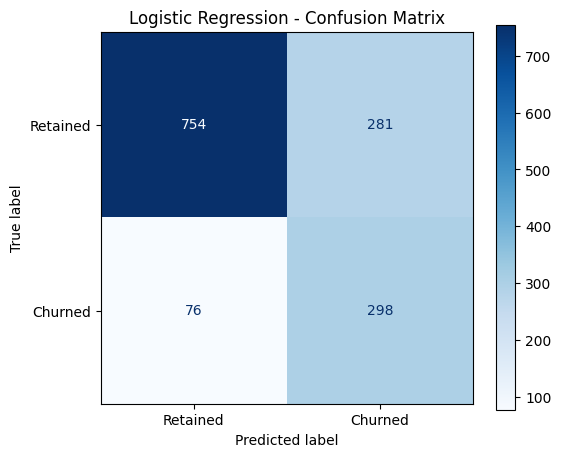

In [42]:
# Plotting the Confusion Matrix for Logistic Regression
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lg,
    display_labels=['Retained', 'Churned'],
    cmap='Blues',
    ax=ax
)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

###  Logistic Regression Results & Business Insight
* **Strong Recall (80%):** Thanks to `class_weight='balanced'`, our model successfully identified 80% of the actual churners. Since our business objective prioritizes catching churners before they leave, this is a massive win!
* **The Precision Trade-off (51%):** The cost of this high recall is lower precision. Out of all the customers our model flagged as "At-Risk", only about half actually churned. This means the Customer Success team will have some "false alarms," but from a business perspective, offering a retention discount to a loyal customer (false positive) is still cheaper than losing a customer entirely (false negative).
* **Overall ROC-AUC (0.84):** A score of 0.84 indicates that our baseline model has a very strong ability to distinguish between churners and non-churners.

## Step 7 — Model 2: Random Forest Classifier

Let's explore a more complex model. Random Forest is an ensemble technique that builds multiple decision trees (200 in this case) and takes their majority vote. A single decision tree can easily overfit the training data, but the average of 200 trees is much more stable. Feature scaling is not required here because tree-based models do not calculate mathematical distances between data points.

** What we are doing in this step:**
We are now moving to a tree-based ensemble model. Unlike Logistic Regression:
* **No Scaling Required:** Random Forest relies on splitting data using decision rules (trees) rather than calculating mathematical distances, so it doesn't care about the scale of our features. We will feed it the original, unscaled training data.
* **Capturing Complex Patterns:** By combining multiple decision trees, this model is much better at capturing complex, non-linear relationships in the customer data that a simple straight line (Logistic Regression) might miss.



In [43]:
# Initialized and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [44]:
# Predict on test data
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [45]:
# see evaluation metrics
print("Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn','Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

Random Forest
              precision    recall  f1-score   support

    No Churn       0.89      0.78      0.83      1035
       Churn       0.55      0.73      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

ROC-AUC: 0.8413


In [46]:
accuracy_score(y_test,y_pred_rf)

0.7672107877927609

### Random Forest Results & Business Insight
* **The Accuracy vs. Recall Trade-off:** While the Random Forest model improved our overall Accuracy (from ~75% to ~77%) and Precision (55%), it came at a cost. Our most critical business metric—**Recall**—dropped from 80% to 73%.
* **Business Impact:** This model generates fewer "false alarms" (better precision), but it misses more actual churners than our simple Logistic Regression baseline. Since our primary goal is to catch as many at-risk customers as possible, Logistic Regression is actually still winning for our specific use case.
* **ROC-AUC:** The overall ability to distinguish classes remains very strong and nearly identical to the baseline (~0.84).

*Let's see if our final model (XGBoost) can give us the best of both worlds!*

## Step 8 — Model 3: XGBoost Classifier

XGBoost is also a tree-based model, but it operates differently than Random Forest. Instead of building trees independently, it builds them sequentially, with each new tree attempting to correct the errors of the previous ones (a process called boosting). To handle our class imbalance, we use the scale_pos_weight parameter, which is XGBoost's native alternative to class_weight.
** What we are doing in this step:**
* **Handling Imbalance in XGBoost:** XGBoost does not use the `class_weight` parameter. Instead, it uses `scale_pos_weight`, which is mathematically calculated as the ratio of negative class (Retained) to positive class (Churned).
* **Evaluation:** We will generate our final predictions and prepare to compare this model against our baseline and Random Forest.

In [47]:
# Calculate scale_pos_weight to handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

"This line calculates the ratio between our majority class (retained) and minority class (churned). This ratio acts as a weight, telling the XGBoost model to give more importance to catching churners in our imbalanced dataset."

In [48]:
# Initialize and train XGBoost
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [49]:
# Predict on test data
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [50]:
accuracy_score(y_test,y_pred_xgb)

0.7608232789212207

In [51]:
# Print evaluation metrics
print("XGBoost")
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn','Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

XGBoost
              precision    recall  f1-score   support

    No Churn       0.87      0.79      0.83      1035
       Churn       0.54      0.67      0.60       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409

ROC-AUC: 0.8238


### XGBoost Results & Business Insight
* **Lower Recall than expected (67%):** Surprisingly, our untuned XGBoost model yielded the lowest Recall among all two models, despite using `scale_pos_weight` to handle class imbalance.
* **Business Impact:** Missing 33% of actual churners is too costly for the business — this baseline configuration isn't good enough yet.
* **Next Step:** Before concluding anything, we need to check whether this is a genuine model limitation or simply a case of under-tuned hyperparameters. We explore this next.

## Step 9 — Model Comparison & Final Decision

**Making a Data-Driven Decision:**
Now that we have trained three distinct models (Logistic Regression, Random Forest, and XGBoost), it is time to compare them side-by-side.
Our business priority is **Recall** (identifying as many actual churners as possible) without completely destroying precision. We will also look at the **ROC-AUC** score to evaluate overall model performance.

In [52]:
# comparison dataframe
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Precision': [precision_score(y_test, y_pred_lg), precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_xgb)],
    'Recall': [recall_score(y_test, y_pred_lg), recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_xgb)],
    'F1-Score': [f1_score(y_test, y_pred_lg), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_xgb)],
    'ROC-AUC': [roc_auc_score(y_test, y_proba_lg), roc_auc_score(y_test, y_proba_rf), roc_auc_score(y_test, y_proba_xgb)]
})

# final table
print(comparison.round(3))

                 Model  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression      0.515   0.797     0.625    0.844
1        Random Forest      0.546   0.730     0.625    0.841
2              XGBoost      0.540   0.671     0.598    0.824


## Step 9.5 — XGBoost Hyperparameter Tuning & Model Selection

Before finalizing Logistic Regression as our winner, let's confirm this wasn't just because XGBoost was under-tuned. We run RandomizedSearchCV on XGBoost, optimizing specifically for Recall (our business priority), to see if a tuned version can beat our baseline.

In [53]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 1.0]
}

xgb_base = XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42)

xgb_search = RandomizedSearchCV(
    xgb_base, param_grid, n_iter=20, scoring='recall',
    cv=5, random_state=42, n_jobs=-1 # Uses all available CPU cores to run the search in parallel for faster execution
)
xgb_search.fit(X_train, y_train)

print("Best Params:", xgb_search.best_params_)

xgb_tuned = xgb_search.best_estimator_
y_pred_xgb_tuned = xgb_tuned.predict(X_test)
y_proba_xgb_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

print("Tuned XGBoost")
print(classification_report(y_test, y_pred_xgb_tuned, target_names=['No Churn','Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb_tuned):.4f}")

Best Params: {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01}
Tuned XGBoost
              precision    recall  f1-score   support

    No Churn       0.91      0.70      0.79      1035
       Churn       0.49      0.81      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.73      0.74      1409

ROC-AUC: 0.8403


## Final Verdict: The Winning Model

Logistic Regression looked like the winner initially, but before finalizing it we hyperparameter-tuned XGBoost (RandomizedSearchCV, optimized for Recall) to make sure this wasn't just a case of an under-tuned model losing to a simpler one.

After tuning, XGBoost came out ahead:

* **Recall:** 81% (XGBoost) vs 79.7% (Logistic Regression) — catches slightly more actual churners
* **ROC-AUC:** 0.840 vs 0.844 — essentially tied
* **Precision:** 49% vs 51.5% — XGBoost gives a few more false alarms, but that's an acceptable trade-off since catching churners matters more here

**Final model: Tuned XGBoost.**

Key takeaway from this exercise: the untuned XGBoost had actually lost to both Random Forest and Logistic Regression earlier. It only became the best model after proper tuning — a good reminder that a "complex model" isn't automatically better, and simple-vs-complex comparisons aren't fair until both sides are tuned.

Logistic Regression is still worth keeping in mind for cases where model transparency matters more than a small performance edge, but for this project XGBoost wins on the metric that matters most for the business: Recall.  now i gave u your recomendation and my old text cell give me final for notebook. and baki merei  note book start to end sahi hai na

### Threshold Sensitivity Check / Analysis

The difference in Recall between the models could simply be due to the default 0.5 probability threshold. Let's adjust XGBoost's probability threshold to see if its Recall aligns closer to Logistic Regression's performance.

In [54]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb_tuned)

target_recall = 0.75
idx = next(i for i, r in enumerate(recalls) if r <= target_recall)
print(f"Threshold for ~75% recall: {thresholds[idx]:.3f}")
print(f"Precision at this threshold: {precisions[idx]:.3f}")

Threshold for ~75% recall: 0.574
Precision at this threshold: 0.539


A threshold-sensitivity check further supported this: at a comparable recall level (~75%), XGBoost achieved a higher precision (0.539) than Logistic Regression's precision at its own operating point (0.515), confirming the improvement was not merely a threshold artifact.

## Step 10 — Visualizing the Results

Numbers tell a story, but visuals confirm it. Here we plot the Confusion Matrix of our winning model (Tuned XGBoost) alongside the ROC Curve comparing all three models plus the tuned version.

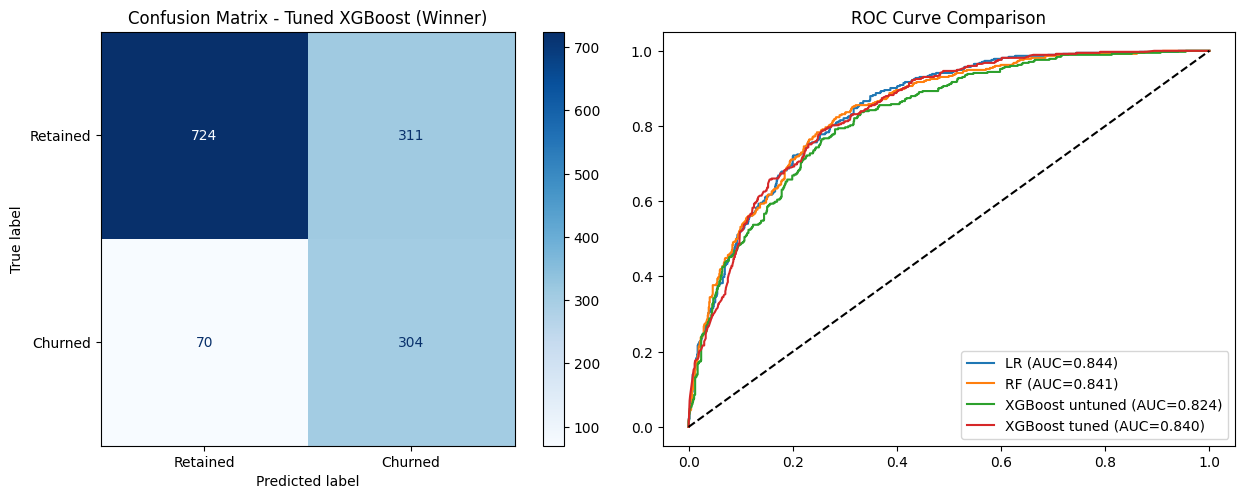

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

# 1. Confusion Matrix for BEST Model (Tuned XGBoost)
cm = confusion_matrix(y_test, y_pred_xgb_tuned)
ConfusionMatrixDisplay(cm, display_labels=['Retained','Churned']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - Tuned XGBoost (Winner)')

# 2. ROC Curve Comparison
fpr_lg, tpr_lg, _ = roc_curve(y_test, y_proba_lg)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
fpr_xgb_tuned, tpr_xgb_tuned, _ = roc_curve(y_test, y_proba_xgb_tuned)

axes[1].plot(fpr_lg, tpr_lg, label=f'LR (AUC={roc_auc_score(y_test, y_proba_lg):.3f})')
axes[1].plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_auc_score(y_test, y_proba_rf):.3f})')
axes[1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost untuned (AUC={roc_auc_score(y_test, y_proba_xgb):.3f})')
axes[1].plot(fpr_xgb_tuned, tpr_xgb_tuned, label=f'XGBoost tuned (AUC={roc_auc_score(y_test, y_proba_xgb_tuned):.3f})')
axes[1].plot([0,1],[0,1],'k--')
axes[1].legend()
axes[1].set_title('ROC Curve Comparison')
plt.tight_layout()
plt.show()

## Step 11 — Feature Importance (Connecting ML back to EDA)

To close the loop, we extract feature importances from our winning tuned XGBoost model. This tells us which variables the model relied on most to make its predictions, and should ideally match the insights found during our Exploratory Data Analysis.

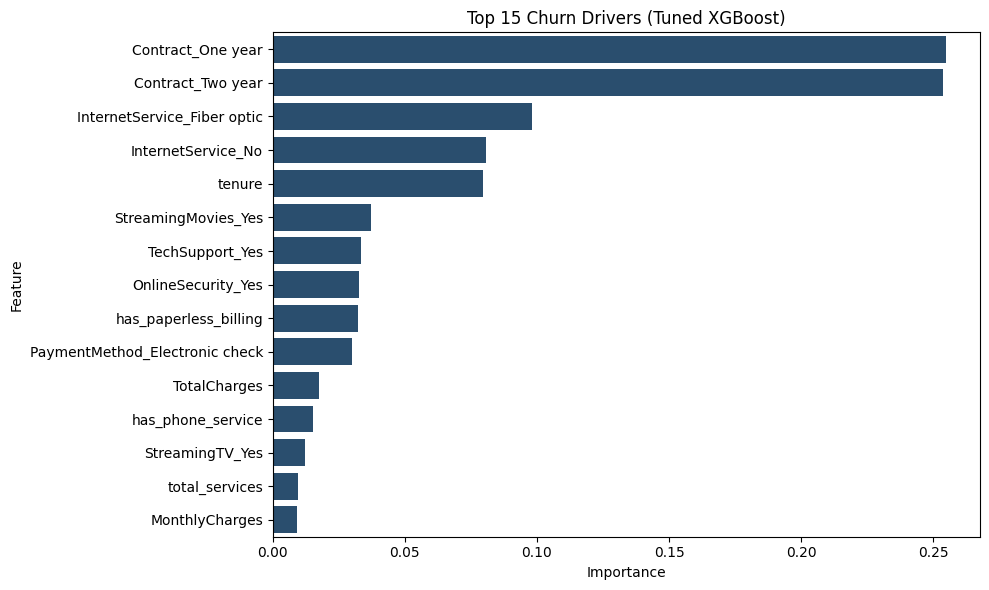

In [56]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', color='#1F4E79')
plt.title('Top 15 Churn Drivers (Tuned XGBoost)')
plt.tight_layout()
plt.show()

Interestingly, customers with no internet service show among the lowest churn risk — likely because they use only basic phone service and are less exposed to the pricing or quality issues driving churn among internet subscribers.

## Step 12 — Business Risk Scoring (Making it Actionable)

A prediction is only useful if the business can act on it. Instead of a plain Yes/No output, we assign a churn probability score (0 to 100 percent) to every customer, then group them into four risk segments: Low, Medium, High, and Critical.

This lets the Customer Success team prioritize their outreach, starting with the Critical and High risk customers first.

In [57]:
# Get churn probability for every customer using the tuned XGBoost model
# No scaling needed here since XGBoost works on raw feature values
all_probs = xgb_tuned.predict_proba(X)[:, 1]

risk_df = df.copy()
risk_df['Churn_Probability_%'] = (all_probs * 100).round(2)

# Assign risk segments based on probability thresholds
risk_df['Risk_Segment'] = pd.cut(all_probs,
                                 bins=[0, 0.3, 0.5, 0.7, 1.0],
                                 labels=['Low', 'Medium', 'High', 'Critical'])

print("Customer Risk Segmentation (Entire Customer Base):")
print(risk_df['Risk_Segment'].value_counts())

Customer Risk Segmentation (Entire Customer Base):
Risk_Segment
Low         2321
High        1888
Medium      1669
Critical    1165
Name: count, dtype: int64


Business Action & Scoring Note:
This scoring is applied to the full historical dataset (including customers used in training) to demonstrate business-ready segmentation across the entire active customer base. In a real-world scenario, the Customer Success team needs risk scores for all current users to prioritize outreach (targeting "Critical" and "High" segments first).

Note on ML Evaluation: This step is strictly for generating actionable business risk scores, not for model evaluation. All rigorous model evaluations (Precision, Recall, ROC-AUC) were computed exclusively on the held-out test set in earlier steps to prevent any biased performance metrics.

## Step 13 — Saving the Model for Deployment

Our model is trained, evaluated, and ready for the real world. We save the winning model (tuned XGBoost) along with the exact column order used during training, so the same structure can be reproduced at prediction time.

No scaler needs to be saved here, since XGBoost does not require feature scaling.

These files will be used to build a real-time Streamlit web app in the next phase of this project.

In [58]:
import joblib

joblib.dump(xgb_tuned, 'churn_model.pkl')
joblib.dump(list(X.columns), 'model_columns.pkl')

print("Model and columns saved successfully as .pkl files!")

Model and columns saved successfully as .pkl files!


## Limitations & Future Work

While this model performs well for our business objective, a few areas remain open for further improvement:
* **Deeper Hyperparameter Tuning:** A more exhaustive GridSearchCV (or Bayesian optimization) across all three models could further improve results.
* **Threshold Optimization:** Instead of the default 0.5 threshold, a business-cost-based threshold (weighing the cost of a false negative vs. false positive) could be calculated for production use.
* **Additional Features:** Incorporating customer
support ticket history or usage trend data (not available in this dataset) could further improve predictive power.
* **Cross-Validation:** A single train-test split was used here; k-fold cross-validation would give a more robust estimate of model performance.
* **Production-Grade Encoding:** For a more robust deployment pipeline, `sklearn.preprocessing.OneHotEncoder` within a `Pipeline` could replace the current `pd.get_dummies()` + manual column-reindexing approach.

